In [2]:
%load_ext autoreload
%autoreload 2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm

NAME = '01102024-benchmark-resnet50_from_scratch-v4_10m'
device = torch.device('cuda:0')
model = torch.load('../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt', map_location=device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


FileNotFoundError: [Errno 2] No such file or directory: '../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt'

## general cross validation benchmark on datasets with different metrics

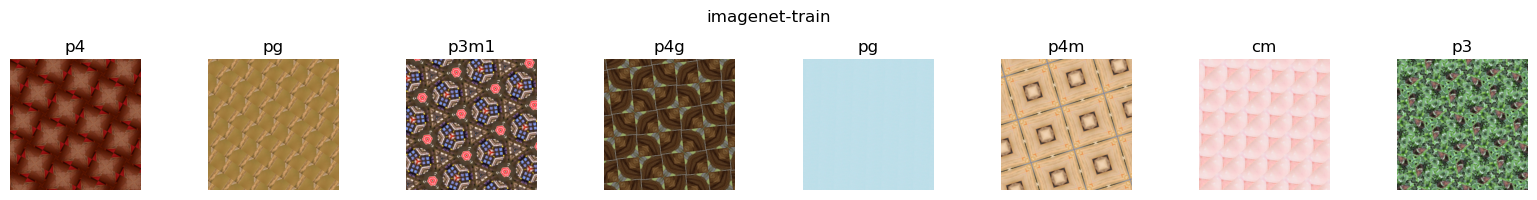

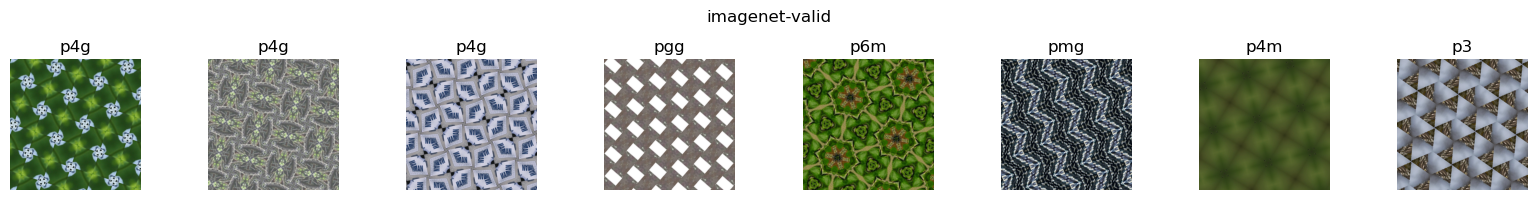

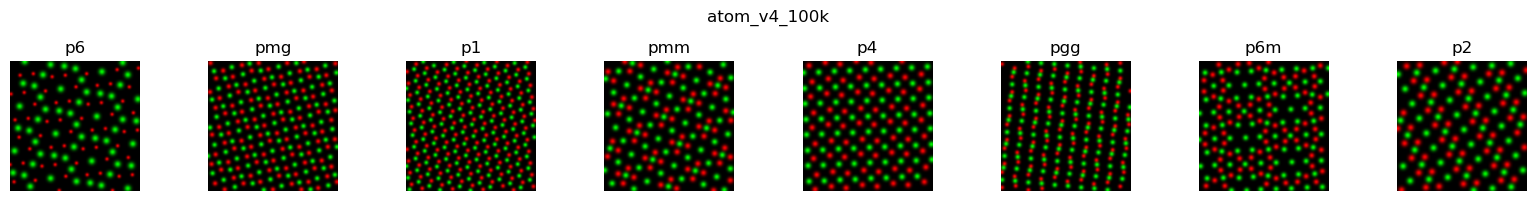

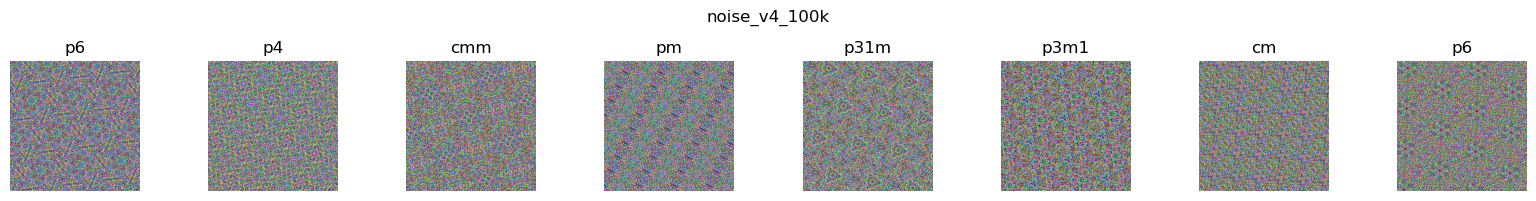

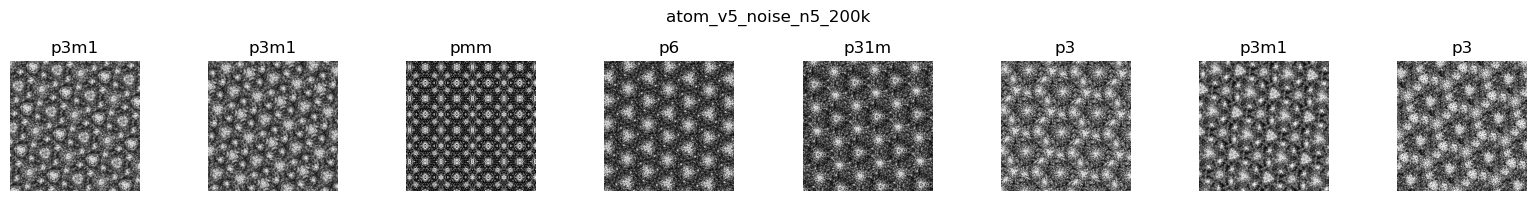

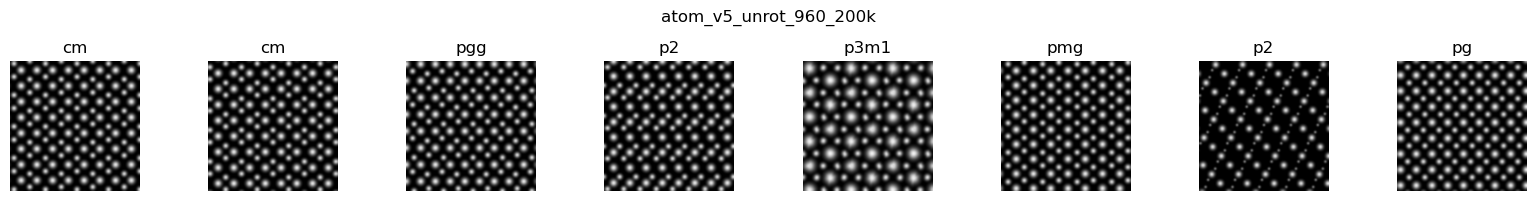

In [4]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# train
train_ds = hdf5_dataset('D:/datasets/symmetry_dataset/imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
_, train_ds = split_train_valid(train_ds, 0.9)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet-train')

# valid
valid_ds = hdf5_dataset('D:/datasets/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
_, valid_ds = split_train_valid(valid_ds, 0.9)
valid_dl = DataLoader(valid_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet-valid')

# atom_v4_100k
atom_v4_100k_ds = hdf5_dataset('../../datasets/imagenet_v4_rot_10m_100k_subset-size-RRR.h5', folder='atom', transform=transforms.ToTensor())
atom_v4_100k_dl = DataLoader(atom_v4_100k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v4_100k_dl, label_converter=label_converter, title='atom_v4_100k')

# noise_v4_100k
noise_v4_100k_ds = hdf5_dataset('../../datasets/imagenet_v4_rot_10m_100k_subset-size-RRR.h5', folder='noise', transform=transforms.ToTensor())
noise_v4_100k_dl = DataLoader(noise_v4_100k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(noise_v4_100k_dl, label_converter=label_converter, title='noise_v4_100k')

# atom_v5_noise_n5_200k
atom_v5_noise_n5_200k_ds = hdf5_dataset('../../datasets/atom_v5_noise_n5_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_noise_n5_200k_dl = DataLoader(atom_v5_noise_n5_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_noise_n5_200k_dl, label_converter=label_converter, title='atom_v5_noise_n5_200k')

# atom_v5_unrot_960_200k
atom_v5_unrot_960_200k_ds = hdf5_dataset('../../datasets/atom_v5_unrot_960_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_unrot_960_200k_dl = DataLoader(atom_v5_unrot_960_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_unrot_960_200k_dl, label_converter=label_converter, title='atom_v5_unrot_960_200k')

In [ ]:
keywords = ['imagenet_v4_train', 'train_v4_valid', 'noise_v4_100k', 'atom_v4_100k', ]
for k in keywords:
    file = glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-{k}*.npy')[0]
    print(file)
    cm = np.load(file)
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    # plot_cm(cm, symmetry_classes, title=file.split('/')[-1].split('.')[0], cm_style='simple', fig_style='printing', font_size=4)

In [ ]:
files = glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-*_cm.npy')[:4]
keywords = ['imagenet_v4', 'atom_v4_100k', 'noise_v4_100k', 'atom_v5_large_uc_200k', 'atom_v5_small_uc_200k', 'atom_v5_noise_n5_200k', 'atom_v5_unrot_200k']

show_cm(files, keywords, summary=True, title_head=None, cm_style='simple', fig_style='printing', font_size=2,
        file_path='../../figures/Dataset_benchmark/ResNet50_cm_datasets_summary')

## cross validation benchmark on datasets with different unit cell size

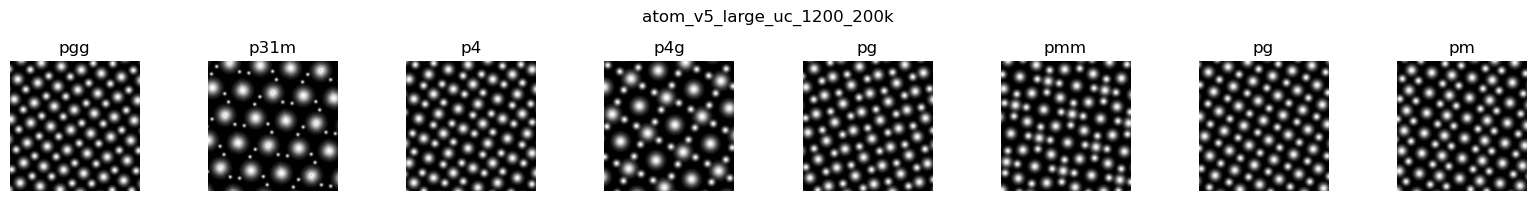

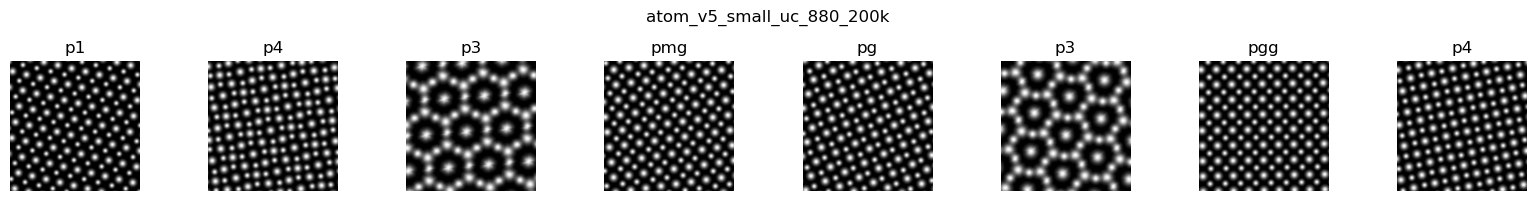

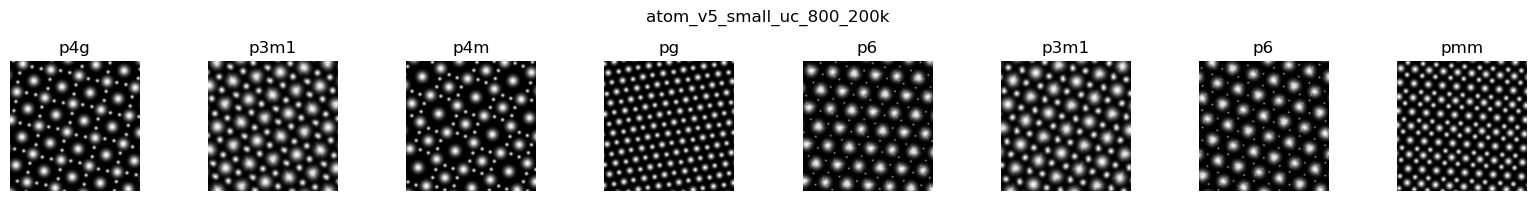

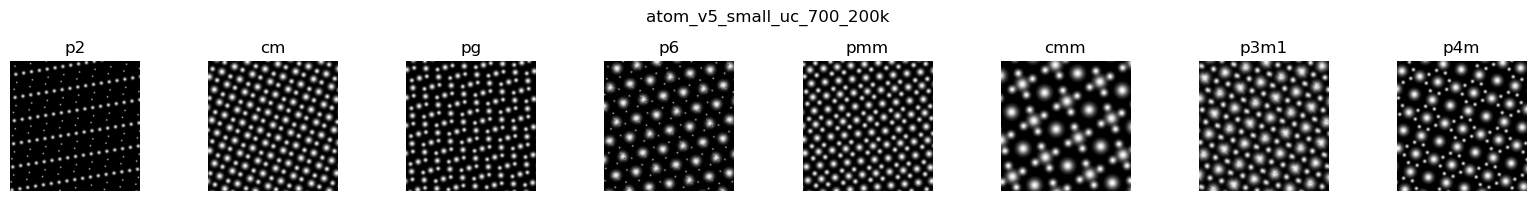

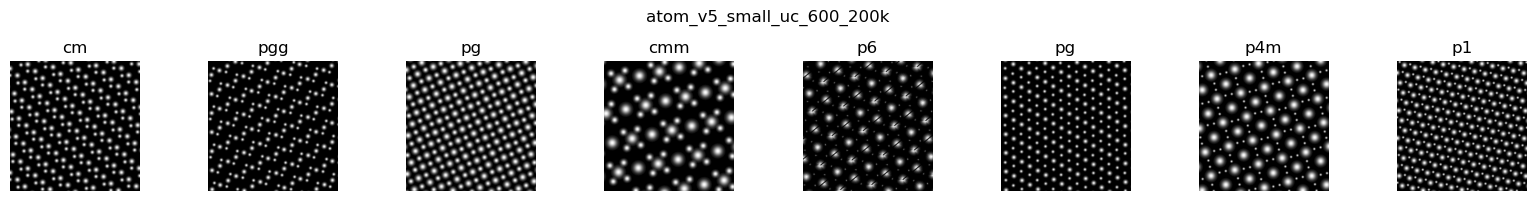

In [7]:
# atom_v5_large_uc_1200_200k
atom_v5_large_uc_1200_200k_ds = hdf5_dataset('../../datasets/atom_v5_large_uc_1200_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_large_uc_1200_200k_dl = DataLoader(atom_v5_large_uc_1200_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_large_uc_1200_200k_dl, label_converter=label_converter, title='atom_v5_large_uc_1200_200k')

# atom_v5_small_uc_880_200k
atom_v5_small_uc_880_200k_ds = hdf5_dataset('../../datasets/atom_v5_small_uc_880_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_880_200k_dl = DataLoader(atom_v5_small_uc_880_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_880_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_880_200k')

# atom_v5_small_uc_800_200k
atom_v5_small_uc_800_200k_ds = hdf5_dataset('../../datasets/atom_v5_small_uc_800_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_800_200k_dl = DataLoader(atom_v5_small_uc_800_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_800_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_200k')

# atom_v5_small_uc_700_200k
atom_v5_small_uc_700_200k_ds = hdf5_dataset('../../datasets/atom_v5_small_uc_700_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_700_200k_dl = DataLoader(atom_v5_small_uc_700_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_700_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_700_200k')

# atom_v5_small_uc_600_200k
atom_v5_small_uc_600_200k_ds = hdf5_dataset('../../datasets/atom_v5_small_uc_600_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_600_200k_dl = DataLoader(atom_v5_small_uc_600_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_600_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_600_200k')

plt.show()

### generate confusion matrix

In [8]:
keywords = ['atom_v5_large_uc_1200_200k', 'atom_v5_small_uc_880_200k', 'atom_v5_small_uc_800_200k', 'atom_v5_small_uc_700_200k', 'atom_v5_small_uc_600_200k']
dl_list = [atom_v5_large_uc_1200_200k_dl, atom_v5_small_uc_880_200k_dl, atom_v5_small_uc_800_200k_dl, atom_v5_small_uc_700_200k_dl, atom_v5_small_uc_600_200k_dl]

for name, dl in zip(keywords, dl_list):
    cm = confusion_matrix(model, dl, symmetry_classes, device, n_batches='all')
    np.save(f'../../saved_results/Dataset_benchmark/resnet50-{name}_cm.npy', cm)

100%|██████████| 399/399 [05:13<00:00,  1.27it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0


Accuracy for these batches: 20.420126057421804%


100%|██████████| 399/399 [04:59<00:00,  1.33it/s]

...

Accuracy for these batches: 54.7813725490196%


100%|██████████| 399/399 [04:41<00:00,  1.42it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0


Accuracy for these batches: 22.709313725490198%


In [9]:
keywords = ['atom_v5_large_uc_1200_200k', 'atom_v5_small_uc_880_200k', 'atom_v5_small_uc_800_200k', 'atom_v5_small_uc_700_200k', 'atom_v5_small_uc_600_200k']
for k in keywords:
    file = glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-{k}*.npy')[0]
    print(file)
    cm = np.load(file)
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    # plot_cm(cm, symmetry_classes, title=file.split('/')[-1].split('.')[0], cm_style='simple', fig_style='printing', font_size=4)

../../saved_results/Dataset_benchmark\resnet50-atom_v5_large_uc_1200_200k_cm.npy
Accuracy: 20.42%

../../saved_results/Dataset_benchmark\resnet50-atom_v5_small_uc_880_200k_cm.npy
Accuracy: 77.36%

../../saved_results/Dataset_benchmark\resnet50-atom_v5_small_uc_800_200k_cm.npy
Accuracy: 74.09%

../../saved_results/Dataset_benchmark\resnet50-atom_v5_small_uc_700_200k_cm.npy
Accuracy: 54.78%

../../saved_results/Dataset_benchmark\resnet50-atom_v5_small_uc_600_200k_cm.npy
Accuracy: 22.71%



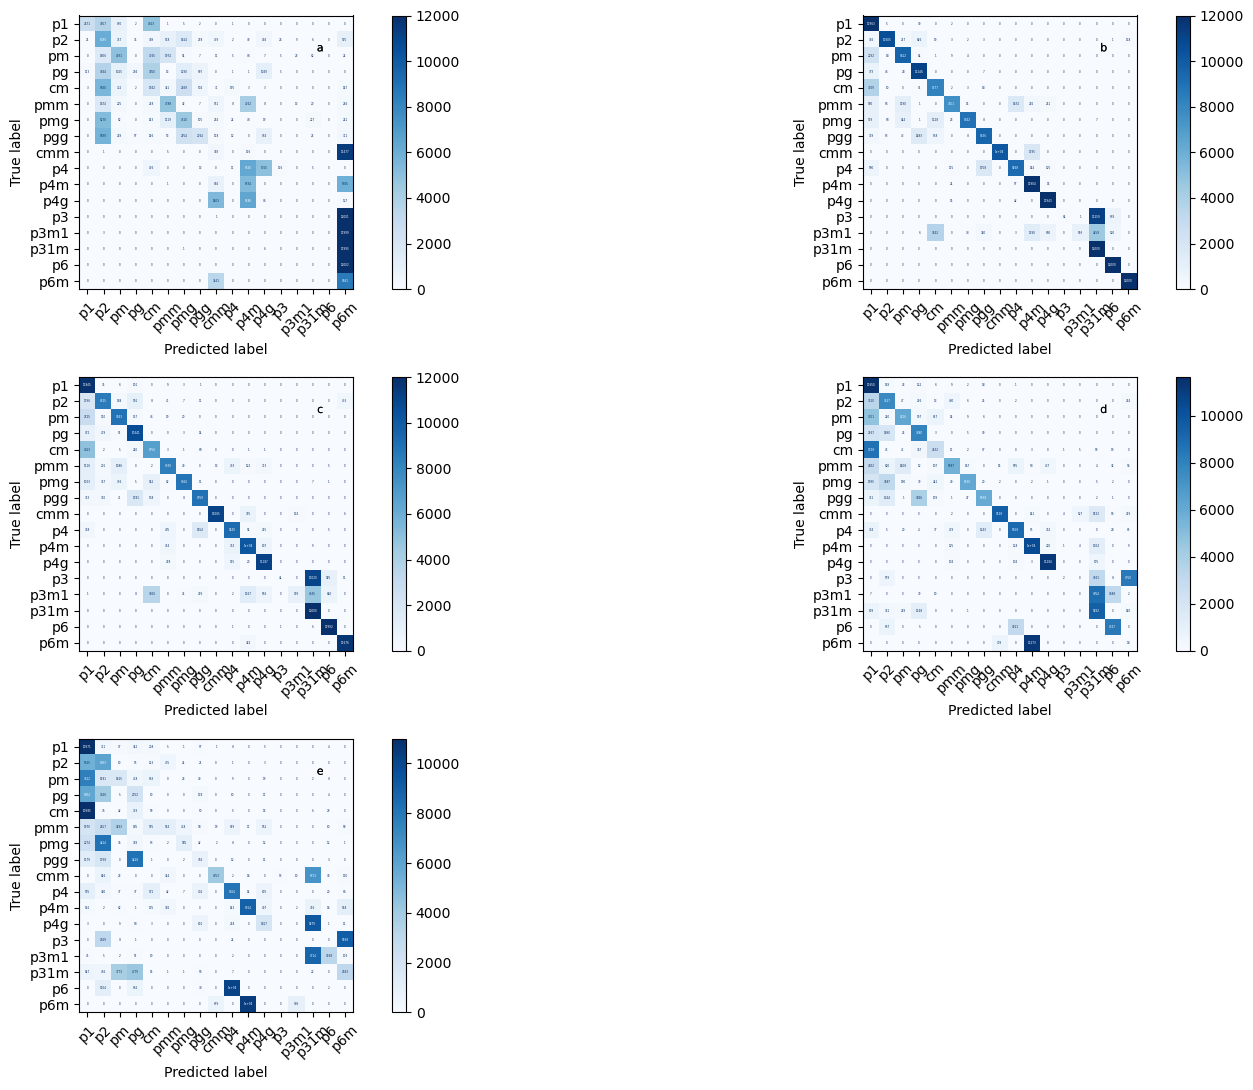

In [10]:
files = []
for k in keywords:
    files.append(glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-{k}*.npy')[0])
show_cm(files, keywords, summary=True, title_head=None, cm_style='simple', fig_style='printing', font_size=2,
        file_path='../../figures/Dataset_benchmark/ResNet50_cm_uc_comparison')